# Clase 6 — Análisis espacial: construir variables territoriales

**Sistemas de Información Geográfica**
Especialización en Ciencias Sociales Computacionales — Universidad Nacional Guillermo Brown

| | |
|---|---|
| **Unidad del programa** | 6 — Análisis espacial |
| **Duración** | 3 horas |
| **Versión** | 2026.1 |
| **Docente** | Renzo Polo |
| **Licencia** | CC BY-SA 4.0 |

---

## 1. La pregunta de hoy

> ### ¿Qué tiene cada barrio alrededor, y a qué distancia?

En las clases anteriores obtuvimos datos (Clase 3), los pusimos en el sistema de coordenadas
correcto (Clase 4) y los representamos (Clase 5).

Una **variable territorial** es un atributo de una unidad del espacio que no figura en ningún
registro y que resulta de relacionar dos capas: la cantidad de farmacias por kilómetro cuadrado
de un barrio, el porcentaje de su superficie que está a menos de 500 metros de un centro de
salud, la distancia hasta el efector más próximo. Ninguna de las tres la mide un organismo; las
tres se calculan.

Trabajamos sobre **Recoleta y Villa Lugano**, los dos barrios que descargamos de OpenStreetMap
en la Clase 3, y sobre los efectores públicos de salud que obtuvimos del geoservicio del IGN en
esa misma clase.

## 2. Objetivos de esta clase

Al terminar, deberías poder:

1. **Geocodificar** un listado de direcciones y evaluar el error de la operación.
2. **Transformar** geometrías —punto representativo, área de influencia, envolvente,
   simplificación, disolución— y elegir la transformación adecuada a cada propósito.
3. **Superponer** capas: intersección y diferencia, y calcular el porcentaje de superficie
   cubierta.
4. **Relacionar** capas con uniones espaciales 1 a 1 y 1 a muchos, y agregar el resultado.
5. **Medir** distancias y determinar el elemento más cercano.
6. **Componer** una tabla de variables territoriales y exportarla.


## 3. Material de esta clase

**Datos.**:

| Archivo | Contenido | Origen |
|---|---|---|
| `osm_barrios_limites.gpkg` | Contorno de Recoleta y Villa Lugano | OSM, `geocode_to_gdf` |
| `osm_amenities_barrios.gpkg` | 1.770 equipamientos con etiqueta `amenity` | OSM, `features_from_place` |
| `ign_salud.gpkg` | 8.311 establecimientos de salud de todo el país | IGN, capa `ign:salud_020801` |

---

## 4. Operaciones espaciales

**Conceptos clave.** Una **operación espacial** es un procedimiento que toma una o más
geometrías y devuelve, calculado a partir de su forma y su posición, una geometría nueva, una
relación o una medida. Casi todo el análisis espacial vectorial se compone de cuatro familias:

| Familia | Devuelve | Operaciones | Bloque |
|---|---|---|---|
| **Transformar** | Una geometría nueva | `representative_point`, `buffer`, `convex_hull`, `envelope`, `simplify`, `union_all` | 6 |
| **Superponer** | La parte común, o la diferencia, entre dos capas | `intersection`, `difference`, `union` | 8 |
| **Relacionar** | Pares de registros de dos capas | `sjoin` con `within`, `intersects`, `contains` | 9 |
| **Medir** | Un número | `area`, `length`, `distance`, `sjoin_nearest` | 10 |

**El producto.** Cada bloque agrega una columna a una tabla de esta forma:

| barrio | superficie_km2 | farmacias_por_km2 | cobertura_500m_perc | dist_salud_m |
|---|---|---|---|---|
| Recoleta | … | … | … | … |
| Villa Lugano | … | … | … | … |

Una fila por unidad de análisis, una columna por variable.

**Una advertencia sobre unidades.** Superficies, distancias y áreas de influencia son
mediciones, y en coordenadas geográficas (EPSG:4326) la unidad es el grado, que no es una
unidad de longitud. `buffer(500)` sobre datos en EPSG:4326 no produce 500 metros. Por eso, al
preparar los datos, reproyectamos una vez a **EPSG:5347** (POSGAR 2007 faja 5, en metros, la
faja que corresponde a la Ciudad de Buenos Aires) y de ahí en adelante todas las mediciones
usan esas capas.

---

## 5. Preparación

### ▶️ Bibliotecas

In [141]:
!pip install -q "geopandas==1.0.1" "mapclassify==2.8.1" "matplotlib==3.9.2" \
               "folium==0.17.0" "geopy==2.4.1"

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import folium

print("Bibliotecas listas")


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Bibliotecas listas


### ▶️ Capas y sistemas de referencia

Cargamos las tres capas y transformamos a su proyección métricas. Como convención, usamos el sufijo `_m` para la capa con la que se **mide**. La otra la usaremos para las visualizaciones interactivas.

La capa de salud del IGN entra **entera**, con sus 8.311 establecimientos del país: en el bloque
6 la vamos a recortar a la zona de estudio.

In [142]:
DATOS = "https://raw.githubusercontent.com/renzoepolo/sig-ciencias-sociales/main/datos/"

GEOGRAFICO = "EPSG:4326"   # como vienen los datos, y lo que usan los mapas web
METRICO    = "EPSG:5347"   # POSGAR 2007 faja 5, en metros: para medir

barrios    = gpd.read_file(DATOS + "osm_barrios_limites.gpkg")
equip      = gpd.read_file(DATOS + "osm_amenities_barrios.gpkg")
salud_pais = gpd.read_file(DATOS + "ign_salud.gpkg")

barrios_m    = barrios.to_crs(METRICO)
equip_m      = equip.to_crs(METRICO)
salud_pais_m = salud_pais.to_crs(METRICO)

print(f"{len(barrios)} barrios · {len(equip)} equipamientos · "
      f"{len(salud_pais)} establecimientos de salud en todo el país")
print("Medición en:", barrios_m.crs.name, "—", barrios_m.crs.axis_info[0].unit_name)

2 barrios · 1770 equipamientos · 8311 establecimientos de salud en todo el país
Medición en: POSGAR 2007 / Argentina 5 — metre


### 👀 Las tres capas

Antes de operar, verificar que las capas estén donde corresponde ya que provienen de dos fuentes
distintas (OSM y el IGN). Las dos escalas son distintas, así que van en dos mapas: la capa de
salud sobre el país, y los barrios con su equipamiento.

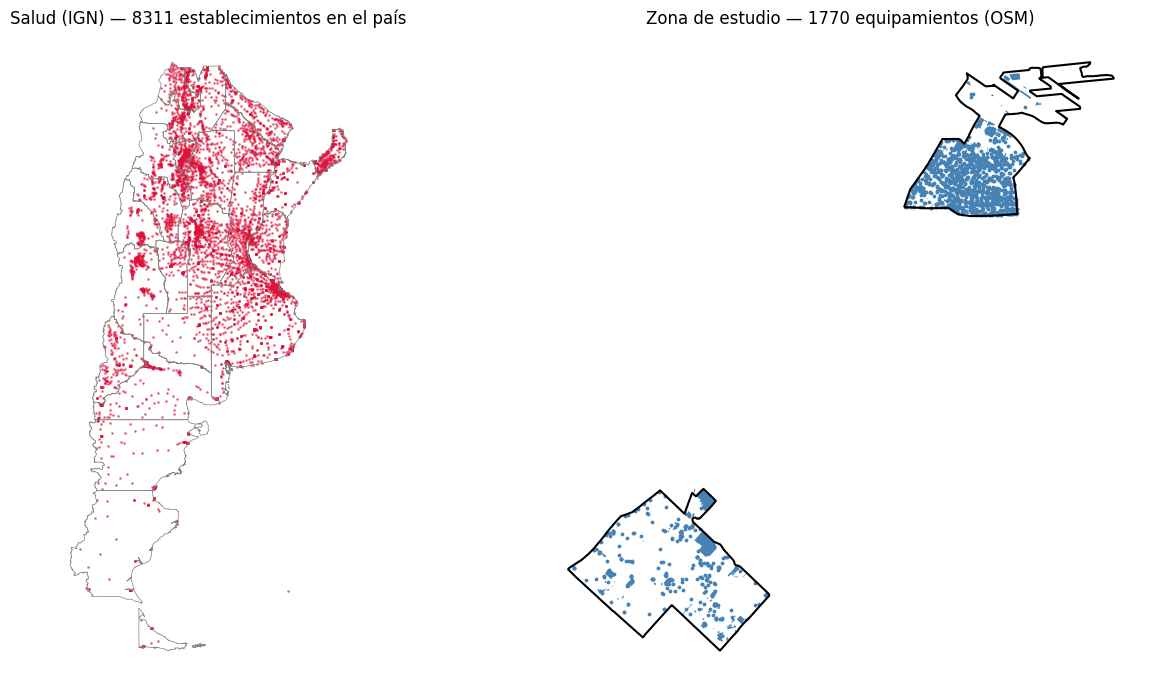

In [143]:
provincias = gpd.read_file(DATOS + "provincias_arg.gpkg")

fig, ejes = plt.subplots(1, 2, figsize=(14, 7))

provincias.boundary.plot(ax=ejes[0], color="grey", linewidth=0.5)
salud_pais.plot(ax=ejes[0], color="crimson", markersize=1, alpha=0.5)
ejes[0].set_title(f"Salud (IGN) — {len(salud_pais)} establecimientos en el país")

barrios.boundary.plot(ax=ejes[1], color="black", linewidth=1.5)
equip.plot(ax=ejes[1], color="steelblue", markersize=3)
ejes[1].set_title(f"Zona de estudio — {len(equip)} equipamientos (OSM)")

for eje in ejes:
    eje.set_axis_off()
plt.tight_layout()
plt.show()

---

## 6. Transformar geometrías

**Conceptos clave.** Esta familia de operaciones toma una geometría y devuelve otra. No produce
ninguna medida por sí misma: acondiciona la geometría para la operación que sigue.

| Operación | Devuelve | Cuándo se usa |
|---|---|---|
| `representative_point()` | Un punto garantizado interior | Homogeneizar una capa de geometrías mixtas |
| `buffer(d)` | La zona a menos de *d* | Definir un área de servicio o de exposición |
| `convex_hull` | La envolvente convexa | Delimitar el área que abarca un conjunto de puntos |
| `envelope` | El rectángulo contenedor | Prefiltrar una capa grande antes de una operación costosa |
| `simplify(t)` | La forma con menos vértices | Publicar un mapa web sin que se trabe |
| `union_all()` | Todo fundido en una geometría | Eliminar superposiciones antes de medir superficie |

**Escenario.** Los dos primeros casos de este bloque son tareas de **preparación de datos**, de
las que hay que hacer casi siempre antes de analizar: homogeneizar los tipos de geometría de una
capa, y recortar una capa nacional a la zona de estudio. Los dos últimos son de publicación y de
medición.

### ▶️ Caso 1 — Homogeneizar tipos de geometría

Al descargar equipamiento de OpenStreetMap no se obtiene una capa de puntos. Un kiosco está
cargado como punto, pero una escuela o un hospital suelen estar cargados como el **polígono del
edificio**, y una parada de colectivos puede ser una línea. La capa mezcla tipos.

In [148]:
equip.explore()

In [149]:
equip_m.geom_type.value_counts()

Point           1463
Polygon          305
LineString         1
MultiPolygon       1
Name: count, dtype: int64

1.463 puntos, 306 polígonos y una línea. Eso trae dos problemas concretos:

- **Las distancias no son comparables.** `distance` mide hasta el **borde** de un polígono y
  hasta el punto en un punto. Un hospital de una manzana aparece más cerca que un kiosco que
  está a la misma distancia de su centro.
- **La pertenencia se vuelve ambigua.** Un polígono puede quedar a superpuesto al límite entre dos
  barrios, y entonces no está `within` de ninguno.

`representative_point()` devuelve, para cada geometría, un punto **garantizado interior**. Para
un punto devuelve el mismo punto; para un polígono, uno adentro.

In [150]:
equip_pt_m = equip_m.copy()
equip_pt_m["geometry"] = equip_m.representative_point() # o centroid

print("Antes:  ", equip_m.geom_type.value_counts().to_dict())
print("Después:", equip_pt_m.geom_type.value_counts().to_dict())
print("Todos los puntos caen dentro de su geometría original:",
      bool(equip_pt_m.geometry.within(equip_m.geometry).all()
           or equip_pt_m.geometry.intersects(equip_m.geometry).all()))

Antes:   {'Point': 1463, 'Polygon': 305, 'LineString': 1, 'MultiPolygon': 1}
Después: {'Point': 1770}
Todos los puntos caen dentro de su geometría original: True


### 👀 El resultado, sobre los polígonos

Acercamiento a un grupo de equipamientos cargados como edificio, con el punto que los reemplaza.

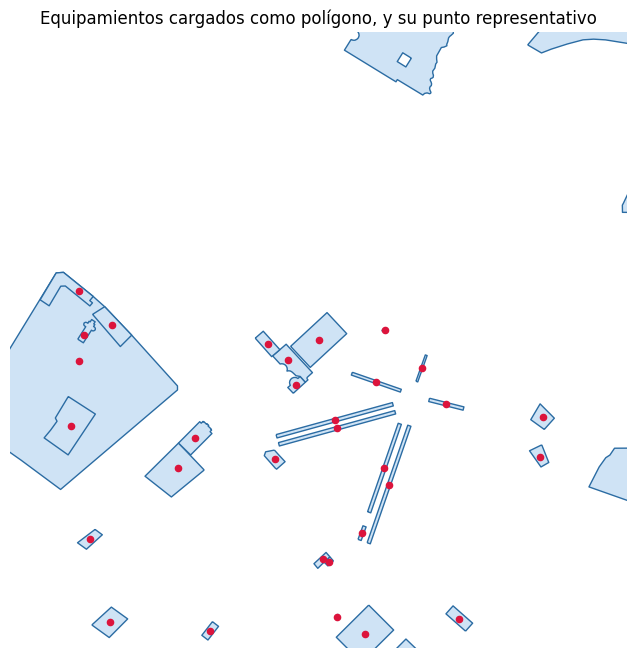

In [151]:
poligonos = equip_m[equip_m.geom_type.isin(["Polygon", "MultiPolygon"])]
zona = poligonos.geometry.iloc[0].buffer(400).bounds

fig, eje = plt.subplots(figsize=(8, 8))
poligonos.plot(ax=eje, facecolor="#cfe3f5", edgecolor="#2b6ca3", linewidth=1)
equip_pt_m.loc[poligonos.index].plot(ax=eje, color="crimson", markersize=20)

eje.set_xlim(zona[0], zona[2])
eje.set_ylim(zona[1], zona[3])
eje.set_title("Equipamientos cargados como polígono, y su punto representativo")
eje.set_axis_off()
plt.show()

De acá en adelante trabajamos con `equip_pt_m`: una capa de 1.770 puntos, homogénea, donde cada
equipamiento pesa lo mismo sin importar cómo lo cargó quien lo mapeó.

El efecto sobre las mediciones es acotado pero real: en los 306 equipamientos que eran
polígonos, la distancia al efector de salud más cercano aumenta en promedio unos 28 metros al
medirla desde el punto interior y no desde el borde del edificio.

### ▶️ Caso 2 — Recortar una capa nacional a la zona de estudio

La capa `salud_pais_m` que cargamos al principio cubre todo el país: 8.311 establecimientos.
Nuestra zona de estudio son dos barrios. Antes de cualquier operación conviene quedarse solo con
lo que puede llegar a interesar.

### 🧭 Qué son la envolvente y el rectángulo contenedor

Antes de usarlas conviene definirlas, porque las dos reemplazan una forma complicada por una
forma simple que la contiene, y se diferencian en cuán ajustada es esa forma.

El **rectángulo contenedor** (`envelope`, también llamado *bounding box*) es el rectángulo más
chico, con lados paralelos a los ejes, que contiene a la geometría. Queda definido por cuatro
números: la mínima y la máxima coordenada en cada eje. Preguntar si un punto está adentro son
cuatro comparaciones, y por eso es la prueba de pertenencia más barata que existe.

La **envolvente convexa** (`convex_hull`) es el polígono **convexo** más chico que contiene a la
geometría. Convexo quiere decir que no tiene entrantes: el segmento entre dos puntos cualesquiera
de la figura queda siempre adentro. La imagen habitual es la de una banda elástica que se suelta
alrededor de la forma y se ajusta hasta donde puede sin entrar en las concavidades.

Las dos son **aproximaciones por exceso**: nunca dejan afuera nada que estuviera adentro, pero
incluyen espacio que no pertenece a la geometría original. Eso es precisamente lo que las hace
útiles como filtro previo —no pierden casos— y lo que las inhabilita como resultado final.

Vamos a comparar las tres formas **barrio por barrio**, que es como corresponde hacerlo: el
rectángulo de los dos barrios juntos abarcaría además todo el corredor que los separa.

In [152]:
filas = []
for _, b in barrios_m.iterrows():
    formas = {
        "exacta":      b.geometry,
        "convex_hull": b.geometry.convex_hull,
        "envelope":    b.geometry.envelope,
    }
    for nombre, geom in formas.items():
        filas.append({
            "barrio": b["barrio"],
            "forma": nombre,
            "superficie_km2": round(geom.area / 1e6, 2),
            "efectores": int(salud_pais_m.intersects(geom).sum()),
        })

pd.DataFrame(filas)

,barrio,forma,superficie_km2,efectores
0,Recoleta,exacta,6.85,4
1,Recoleta,convex_hull,10.88,6
2,Recoleta,envelope,17.85,9
3,Villa Lugano,exacta,9.32,9
4,Villa Lugano,convex_hull,11.38,10
5,Villa Lugano,envelope,18.05,13


/tmp/ipykernel_44072/4135025702.py:15: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  eje.legend(loc="lower left", fontsize=9)
/tmp/ipykernel_44072/4135025702.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  eje.legend(loc="lower left", fontsize=9)
/tmp/ipykernel_44072/4135025702.py:15: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  eje.legend(loc="lower left", fontsize=9)
/tmp/ipykernel_44072/4135025702.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argumen

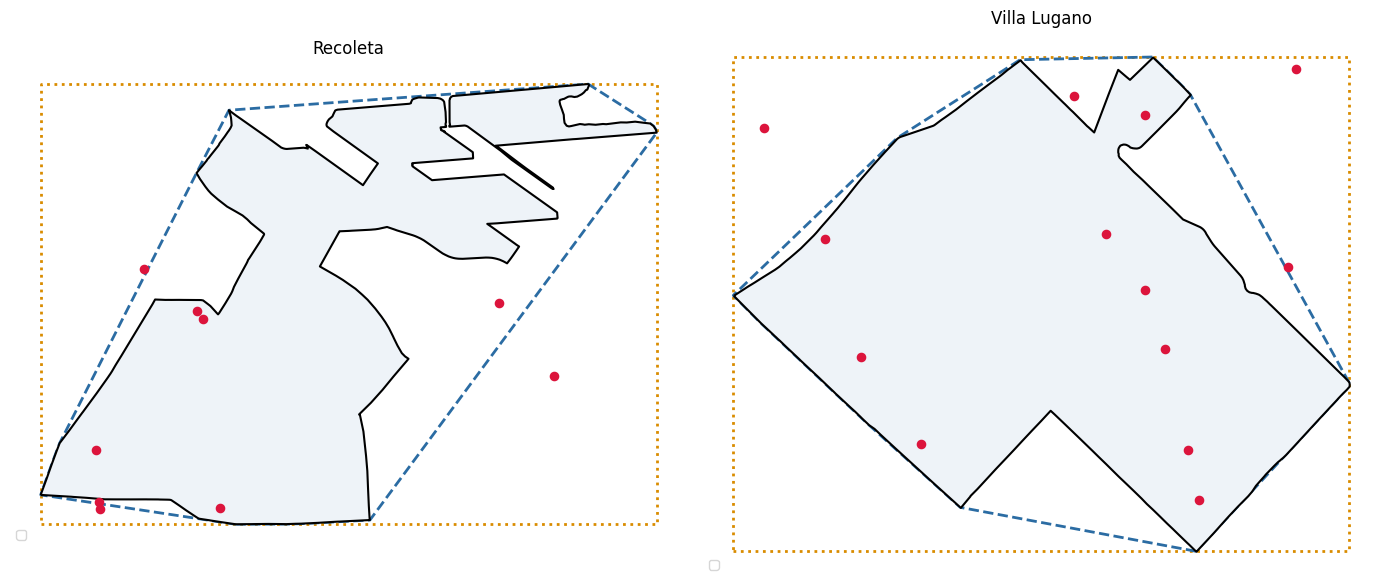

In [153]:
fig, ejes = plt.subplots(1, 2, figsize=(14, 7))

for eje, (_, b) in zip(ejes, barrios_m.iterrows()):
    gpd.GeoSeries([b.geometry.envelope], crs=METRICO).plot(
        ax=eje, facecolor="none", edgecolor="#d98c00", linewidth=2,
        linestyle=":", label="envelope")
    gpd.GeoSeries([b.geometry.convex_hull], crs=METRICO).plot(
        ax=eje, facecolor="none", edgecolor="#2b6ca3", linewidth=2,
        linestyle="--", label="convex_hull")
    gpd.GeoSeries([b.geometry], crs=METRICO).plot(
        ax=eje, facecolor="#eef3f8", edgecolor="black", linewidth=1.5, label="exacta")
    salud_pais_m[salud_pais_m.intersects(b.geometry.envelope)].plot(
        ax=eje, color="crimson", markersize=35)
    eje.set_title(b["barrio"])
    eje.legend(loc="lower left", fontsize=9)
    eje.set_axis_off()

plt.tight_layout()
plt.show()

### 🔍 Interpretación

El mapa muestra las tres formas encajadas una dentro de la otra, y la tabla las cuantifica.

En **Recoleta** el rectángulo mide 17,85 km² y captura 9 establecimientos, la envolvente convexa
10,88 km² y 6, y la geometría exacta 6,85 km² y 4. En **Villa Lugano**, 18,05 km² y 13, contra
11,38 y 10, contra 9,32 y 9. En los dos casos la progresión es la misma: cada forma más ajustada
descarta algunos de los que la anterior había dejado pasar, y ninguna pierde nada que estuviera
adentro de la geometría exacta.

De ahí el criterio de uso. El `envelope` se aplica **primero**, porque cuesta casi nada y
descarta la enorme mayoría de una capa grande: sobre los 8.311 establecimientos del país, los
rectángulos de los dos barrios dejan 22 candidatos. La geometría exacta se aplica **después**,
sobre esos 22, y da el resultado correcto.

La envolvente convexa, en cambio, no es un buen filtro intermedio acá: cuesta más que el
rectángulo y ajusta poco, porque los dos barrios son razonablemente convexos de por sí. Su uso
propio es otro: delimitar el área que abarca **un conjunto disperso de puntos** —el alcance de
una red, la extensión de una muestra de encuestas— donde no existe un polígono de referencia
contra el cual recortar.

### ▶️ El recorte, en dos pasos

Aplicamos el criterio: primero el filtro barato sobre la capa nacional, después el exacto sobre
lo que quedó. El resultado es **la capa de efectores de la zona de estudio**, y es con la que
vamos a trabajar durante el resto de la clase.

In [154]:
# Paso 1 — filtro barato: los rectángulos de los dos barrios
recuadros = barrios_m.geometry.envelope.union_all()
candidatos_m = salud_pais_m[salud_pais_m.intersects(recuadros)]

# Paso 2 — filtro exacto: la geometría de los barrios
zona_estudio = barrios_m.geometry.union_all()
salud_m = candidatos_m[candidatos_m.within(zona_estudio)].copy()


print(f"Capa nacional:        {len(salud_pais_m)}")
print(f"Dentro del rectángulo: {len(candidatos_m)}")
print(f"Dentro de los barrios: {len(salud_m)}")

Capa nacional:        8311
Dentro del rectángulo: 22
Dentro de los barrios: 13


In [156]:
salud_m = salud_m.rename(columns={"fna": "nombre", "gna": "tipo"})

# A cuál de los dos barrios pertenece cada uno, recorriéndolos de a uno
for nombre_barrio, geometria in zip(barrios_m["barrio"], barrios_m.geometry):
    salud_m.loc[salud_m.within(geometria), "barrio"] = nombre_barrio

salud = salud_m.to_crs(GEOGRAFICO)      # versión para los mapas interactivos

salud_m[["nombre", "tipo", "barrio"]]

,nombre,tipo,barrio
301,Hospital General de Agudos Bernardino Rivadavia,Hospital General de Agudos,Recoleta
305,Hospital Odontológico Doctor Ramón Carrillo,Hospital Odontológico,Recoleta
307,Centro de Salud y Acción Comunitaria Nº 29,Centro de Salud y Acción Comunitaria,Villa Lugano
309,Centro de Salud y Acción Comunitaria Nº 5,Centro de Salud y Acción Comunitaria,Villa Lugano
326,Centro Médico Barrial Nº 9,Centro Médico Barrial,Villa Lugano
2528,Centro de Salud y Acción Comunitaria Nº 7,Centro de Salud y Acción Comunitaria,Villa Lugano
3113,Hospital de Clínicas José de San Martín,Hospital de Clínicas,Recoleta
3123,Centro de Salud y Acción Comunitaria Nº 44,Centro de Salud y Acción Comunitaria,Villa Lugano
3655,Centro de Salud y Acción Comunitaria Nº 3,Centro de Salud y Acción Comunitaria,Villa Lugano
3665,Centro de Salud y Acción Comunitaria Nº 18,Centro de Salud y Acción Comunitaria,Villa Lugano


Para asignar el barrio recorrimos los dos polígonos con un bucle y marcamos los puntos que caen
adentro de cada uno. Funciona porque son dos barrios y trece puntos. En el bloque 9 vamos a ver
`sjoin`, que hace lo mismo en una línea, con cualquier cantidad de unidades y trayendo además
todas las columnas del polígono.

### ▶️ Caso 3 — `simplify`: aligerar para publicar

Un mapa interactivo con geometrías detalladas tarda en cargar y puede trabar el navegador. Es lo
que hicimos en la Clase 5 con los 527 departamentos. `simplify` reduce la cantidad de vértices
con una tolerancia expresada en las unidades del CRS: cuánto se admite que la línea nueva se
aparte de la original.

In [157]:
simplificado = barrios_m.simplify(200)

pd.DataFrame({
    "vertices": [int(barrios_m.count_coordinates().sum()),
                 int(simplificado.count_coordinates().sum())],
    "superficie_km2": [round(barrios_m.area.sum() / 1e6, 2),
                       round(simplificado.area.sum() / 1e6, 2)],
}, index=["original", "simplificado 200 m"])

,vertices,superficie_km2
original,797,16.17
simplificado 200 m,40,15.73


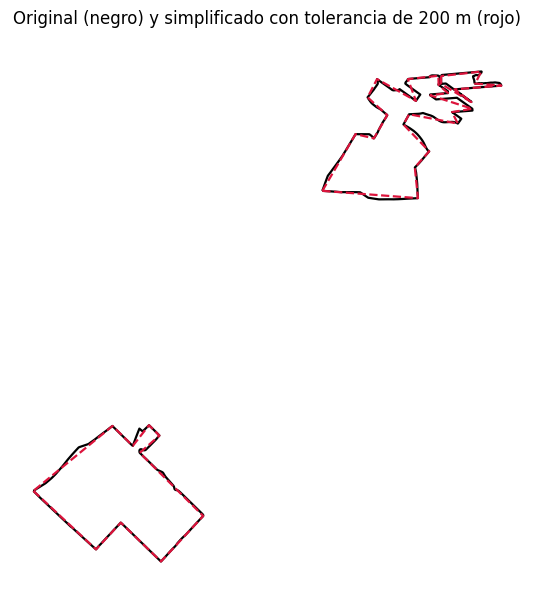

In [119]:
fig, eje = plt.subplots(figsize=(9, 7))

barrios_m.plot(ax=eje, facecolor="none", edgecolor="black", linewidth=1.6)
simplificado.plot(ax=eje, facecolor="none", edgecolor="crimson",
                  linewidth=1.6, linestyle="--")

eje.set_title("Original (negro) y simplificado con tolerancia de 200 m (rojo)")
eje.set_axis_off()
plt.show()

De 797 vértices a 40 —un 95 % menos— con una pérdida del 3 % de superficie. Las curvas suaves se
convierten en rectas y el detalle menor a 200 metros desaparece. Para un mapa de conjunto es un
intercambio conveniente; para medir superficies no lo es, y la medición se hace siempre sobre la
geometría original.

---

## 7. Geocodificación: de la dirección al punto

**Conceptos clave.** La **geocodificación** convierte una descripción textual de un lugar, una
dirección o el nombre de una institución en coordenadas. La operación inversa, la
**geocodificación inversa**, parte de un par de coordenadas y devuelve la dirección postal
correspondiente.

**Escenario.** Es el paso previo a cualquier análisis espacial sobre datos que no nacieron
georreferenciados: las encuestas registran domicilios, los padrones registran direcciones, los
registros administrativos registran nombres de establecimientos. Ninguno de esos datos es
todavía una capa.

El servicio que vamos a usar es **Nominatim**, el geocodificador de OpenStreetMap: gratuito, sin
registro y con un límite de un pedido por segundo.

### ▶️ Cómo funciona: una sola dirección

Antes de aplicarlo a los 13 registros, conviene ver qué hace la función con un caso.
`geocode()` recibe una cadena de texto y devuelve un objeto con la ubicación encontrada.

In [158]:
from geopy.geocoders import Nominatim

# El user_agent es obligatorio: identifica a quien consulta el servicio
nominatim = Nominatim(user_agent="sig-unab-2026-clase6")

ubicacion = nominatim.geocode(
    "Avenida Córdoba 2351, Ciudad Autónoma de Buenos Aires, Argentina",
    addressdetails=True)   # pide además la dirección desglosada en campos

print("Dirección normalizada:", ubicacion.address)
print("Latitud:  ", ubicacion.latitude)
print("Longitud: ", ubicacion.longitude)

Dirección normalizada: Hospital de Clínicas José de San Martín, 2351, Avenida Córdoba, Barrio Norte, Recoleta, Buenos Aires, Comuna 2, Ciudad Autónoma de Buenos Aires, C1120AAR, Argentina
Latitud:   -34.5988462
Longitud:  -58.4001532


Tres cosas para observar en el resultado.

La **dirección normalizada** que devuelve no es la que pedimos: es la que el servicio tiene
registrada, con la jerarquía administrativa completa —barrio, comuna, ciudad, código postal,
país—. Sirve para verificar que resolvió lo que queríamos y no otra cosa.

Las **coordenadas** vienen en EPSG:4326, latitud y longitud, que es el estándar de los servicios
web. Para incorporarlas a un GeoDataFrame hay que armar el punto con
`gpd.points_from_xy(lon, lat)`, en ese orden: primero longitud, después latitud.

Y con `addressdetails=True` el objeto trae un diccionario `raw` con la dirección **desglosada en
campos**, que es de donde vamos a sacar la calle y la altura por separado. Sin ese argumento el
servicio devuelve la dirección solo como una cadena de texto.

In [159]:
ubicacion.raw["address"]

{'amenity': 'Hospital de Clínicas José de San Martín',
 'house_number': '2351',
 'road': 'Avenida Córdoba',
 'quarter': 'Barrio Norte',
 'suburb': 'Recoleta',
 'city': 'Buenos Aires',
 'state_district': 'Comuna 2',
 'state': 'Ciudad Autónoma de Buenos Aires',
 'ISO3166-2-lvl4': 'AR-C',
 'postcode': 'C1120AAR',
 'country': 'Argentina',
 'country_code': 'ar'}

### 👀 Qué tenemos y qué nos falta en la capa de salud

Antes de geocodificar, conviene mirar la capa de efectores de salud y ver con qué información
cuenta realmente.

In [160]:
print("Columnas:", list(salud.columns))
salud.head()

Columnas: ['gml_id', 'gid', 'entidad', 'nombre', 'tipo', 'nam', 'fdc', 'sag', 'geometry', 'barrio']


,gml_id,gid,entidad,nombre,tipo,nam,fdc,sag,geometry,barrio
301,salud_020801.9028,9028,0,Hospital General de Agudos Bernardino Rivadavia,Hospital General de Agudos,Bernardino Rivadavia,IGN/SISA,IGN,POINT (-58.40189 -34.58483),Recoleta
305,salud_020801.9032,9032,0,Hospital Odontológico Doctor Ramón Carrillo,Hospital Odontológico,Doctor Ramón Carrillo,IGN/SISA,IGN,POINT (-58.40246 -34.58421),Recoleta
307,salud_020801.9034,9034,0,Centro de Salud y Acción Comunitaria Nº 29,Centro de Salud y Acción Comunitaria,Nº 29,IGN/SISA,IGN,POINT (-58.48661 -34.6846),Villa Lugano
309,salud_020801.9036,9036,0,Centro de Salud y Acción Comunitaria Nº 5,Centro de Salud y Acción Comunitaria,Nº 5,IGN/SISA,IGN,POINT (-58.49494 -34.67051),Villa Lugano
326,salud_020801.9053,9053,0,Centro Médico Barrial Nº 9,Centro Médico Barrial,Nº 9,IGN/SISA,IGN,POINT (-58.47134 -34.66986),Villa Lugano


La capa trae el nombre, el tipo de establecimiento, el barrio y la **geometría**: cada efector
ya está ubicado, porque el IGN lo publicó con sus coordenadas.

Lo que **no** trae es la dirección postal.

Tenemos entonces el caso inverso al habitual: tenemos la coordenada y falta el texto. Es
exactamente lo que resuelve la **geocodificación inversa**.

### ▶️ De la coordenada a la dirección, para los 13

`RateLimiter` espera el intervalo que exige el servicio entre un pedido y el siguiente. Sin él,
el servidor bloquea la consulta. Son 13 registros: unos 15 segundos.

In [161]:
from geopy.extra.rate_limiter import RateLimiter

inverso = RateLimiter(nominatim.reverse, min_delay_seconds=1.1)

respuestas = [inverso((punto.y, punto.x)) for punto in salud.geometry]

salud["calle"]  = [r.raw["address"].get("road") for r in respuestas]
salud["altura"] = [r.raw["address"].get("house_number") for r in respuestas]
salud["tiene_direccion"] = salud["calle"].notna() & salud["altura"].notna()

salud[["barrio", "nombre", "calle", "altura"]]

,barrio,nombre,calle,altura
301,Recoleta,Hospital General de Agudos Bernardino Rivadavia,Avenida General Las Heras,2670
305,Recoleta,Hospital Odontológico Doctor Ramón Carrillo,Avenida General Las Heras,2670
307,Villa Lugano,Centro de Salud y Acción Comunitaria Nº 29,Los Álamos,6999
309,Villa Lugano,Centro de Salud y Acción Comunitaria Nº 5,Avenida Piedra Buena,3140
326,Villa Lugano,Centro Médico Barrial Nº 9,Albariño,3512
2528,Villa Lugano,Centro de Salud y Acción Comunitaria Nº 7,2 de Abril de 1982,None
3113,Recoleta,Hospital de Clínicas José de San Martín,Avenida Córdoba,2351
3123,Villa Lugano,Centro de Salud y Acción Comunitaria Nº 44,Saraza,None
3655,Villa Lugano,Centro de Salud y Acción Comunitaria Nº 3,Avenida Soldado de la Frontera,5144
3665,Villa Lugano,Centro de Salud y Acción Comunitaria Nº 18,José Pablo Torcuato Batlle y Ordóñez,5080


### ✅ Comprobación

Los 13 devolvieron calle; tres no devolvieron altura. Sin altura la dirección no es
geocodificable de vuelta, así que esos tres quedan fuera del paso siguiente.

La tasa de éxito de una geocodificación se informa junto con el resultado: un análisis que
declara "se geocodificaron 10 de 13 registros" es reproducible.

In [162]:
print(f"Con calle: {salud['calle'].notna().sum()} de {len(salud)}")
print(f"Con dirección completa: {salud['tiene_direccion'].sum()} de {len(salud)}")

Con calle: 13 de 13
Con dirección completa: 10 de 13


### ▶️ De la dirección a la coordenada

Repetimos la operación del ejemplo individual, ahora sobre las diez direcciones completas. La
consulta incluye barrio, ciudad y país: cuanto más contexto, menor la ambigüedad, porque hay
calles homónimas en muchas localidades del país.

In [163]:
directo = RateLimiter(nominatim.geocode, min_delay_seconds=1.1)

# El texto exacto que se le envía al servicio, una fila por efector
salud["consulta"] = (salud["calle"] + " " + salud["altura"].astype(str)
                     + ", " + salud["barrio"]
                     + ", Ciudad Autónoma de Buenos Aires, Argentina")

hallados = []
for consulta, tiene_direccion in zip(salud["consulta"], salud["tiene_direccion"]):
    if not tiene_direccion:
        hallados.append(None)
        continue
    print("Consultando:", consulta)
    hallados.append(directo(consulta))

salud["lon_geo"] = [r.longitude if r else None for r in hallados]
salud["lat_geo"] = [r.latitude  if r else None for r in hallados]

print(f"\nResolvió {salud['lat_geo'].notna().sum()} de {salud['tiene_direccion'].sum()}")

Consultando: Avenida General Las Heras 2670, Recoleta, Ciudad Autónoma de Buenos Aires, Argentina
Consultando: Avenida General Las Heras 2670, Recoleta, Ciudad Autónoma de Buenos Aires, Argentina
Consultando: Los Álamos 6999, Villa Lugano, Ciudad Autónoma de Buenos Aires, Argentina
Consultando: Avenida Piedra Buena 3140, Villa Lugano, Ciudad Autónoma de Buenos Aires, Argentina
Consultando: Albariño 3512, Villa Lugano, Ciudad Autónoma de Buenos Aires, Argentina
Consultando: Avenida Córdoba 2351, Recoleta, Ciudad Autónoma de Buenos Aires, Argentina
Consultando: Avenida Soldado de la Frontera 5144, Villa Lugano, Ciudad Autónoma de Buenos Aires, Argentina
Consultando: José Pablo Torcuato Batlle y Ordóñez 5080, Villa Lugano, Ciudad Autónoma de Buenos Aires, Argentina
Consultando: Gallo 1330, Recoleta, Ciudad Autónoma de Buenos Aires, Argentina
Consultando: Fonrouge 4396, Villa Lugano, Ciudad Autónoma de Buenos Aires, Argentina

Resolvió 10 de 10


### ▶️ El resultado

Cada consulta devolvió un par de coordenadas. Las incorporamos a un GeoDataFrame con
`points_from_xy`, que arma la geometría de punto a partir de dos columnas: **primero la
longitud, después la latitud**.

In [164]:
geocodificados = gpd.GeoDataFrame(
    salud, geometry=gpd.points_from_xy(salud["lon_geo"], salud["lat_geo"]), crs=GEOGRAFICO)

geocodificados.loc[geocodificados["tiene_direccion"],
                   ["barrio", "nombre", "consulta", "lat_geo", "lon_geo"]]

,barrio,nombre,consulta,lat_geo,lon_geo
301,Recoleta,Hospital General de Agudos Bernardino Rivadavia,"Avenida General Las Heras 2670, Recoleta, Ciud...",-34.584689,-58.401676
305,Recoleta,Hospital Odontológico Doctor Ramón Carrillo,"Avenida General Las Heras 2670, Recoleta, Ciud...",-34.584689,-58.401676
307,Villa Lugano,Centro de Salud y Acción Comunitaria Nº 29,"Los Álamos 6999, Villa Lugano, Ciudad Autónoma...",-34.684606,-58.486541
309,Villa Lugano,Centro de Salud y Acción Comunitaria Nº 5,"Avenida Piedra Buena 3140, Villa Lugano, Ciuda...",-34.670484,-58.494800
326,Villa Lugano,Centro Médico Barrial Nº 9,"Albariño 3512, Villa Lugano, Ciudad Autónoma d...",-34.669869,-58.471290
3113,Recoleta,Hospital de Clínicas José de San Martín,"Avenida Córdoba 2351, Recoleta, Ciudad Autónom...",-34.598846,-58.400153
3655,Villa Lugano,Centro de Salud y Acción Comunitaria Nº 3,"Avenida Soldado de la Frontera 5144, Villa Lug...",-34.684776,-58.464120
3665,Villa Lugano,Centro de Salud y Acción Comunitaria Nº 18,"José Pablo Torcuato Batlle y Ordóñez 5080, Vil...",-34.673742,-58.468006
3961,Recoleta,Hospital General de Niños Doctor Ricardo Gutié...,"Gallo 1330, Recoleta, Ciudad Autónoma de Bueno...",-34.594175,-58.411393
3967,Villa Lugano,Centro de Salud y Acción Comunitaria Nº 43,"Fonrouge 4396, Villa Lugano, Ciudad Autónoma d...",-34.677780,-58.466310


### 👀 La capa que acabamos de construir

Los diez puntos obtenidos a partir del texto de la dirección, sobre los dos barrios. Es la capa
que habríamos tenido que armar si la fuente nos hubiera dado direcciones en lugar de
coordenadas.

In [166]:
resueltos = geocodificados[geocodificados["lat_geo"].notna()]

mapa = barrios.explore(color="grey", style_kwds=dict(fill=False, weight=3),
                       name="Barrios")

resueltos.explore(m=mapa, color="navy", marker_kwds=dict(radius=6),
                  tooltip=["nombre", "consulta"], name="Geocodificados")

folium.LayerControl().add_to(mapa)
mapa

---

## 8. Áreas de influencia, disolución y superposición

**Conceptos clave.** Un **área de influencia** (*buffer*) es la zona que rodea a una geometría
hasta una distancia dada. La **superposición** (*overlay*) corta una capa contra otra:
`intersection` devuelve la parte común y `difference` la parte que queda fuera. Entre las dos
operaciones hay un paso necesario, la **disolución** (`union_all`), que funde varias geometrías
en una sola y elimina las superposiciones.

**Escenario.** Queremos analizar la cobertura de los efectores públicos de salud. Suponemos que
un efector es accesible a pie para quien vive a una distancia razonable: **500 metros**, unos
seis minutos de caminata, el umbral que suele usarse para servicios de proximidad. La pregunta
es qué parte de cada barrio queda dentro de ese radio y qué parte queda fuera.

Los 500 metros son un supuesto, no un dato. Al final del bloque medimos cuánto depende el
resultado de esa elección.

### ▶️ Paso 1 — Las áreas de influencia

`buffer` interpreta el número en las unidades del CRS de la capa. Por eso se aplica sobre
`salud_m`, que está en metros.

In [167]:
RADIO_M = 500

areas_m = salud_m.copy()
areas_m["geometry"] = salud_m.buffer(RADIO_M)

print(f"{len(areas_m)} áreas de influencia de {RADIO_M} m")
print(f"Superficie de cada una: {areas_m.area.iloc[0] / 10_000:.1f} ha")

13 áreas de influencia de 500 m
Superficie de cada una: 78.4 ha


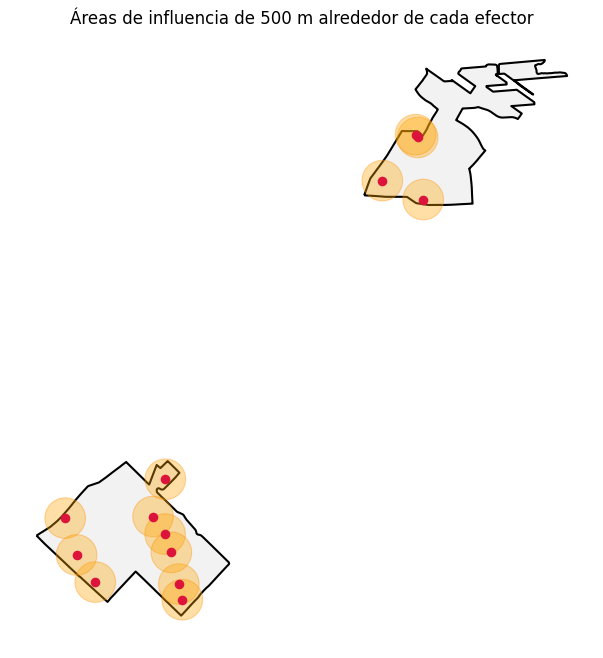

In [168]:
fig, eje = plt.subplots(figsize=(9, 8))

barrios_m.plot(ax=eje, facecolor="#f2f2f2", edgecolor="black", linewidth=1.5)
areas_m.plot(ax=eje, facecolor="orange", alpha=0.35, edgecolor="darkorange", linewidth=0.8)
salud_m.plot(ax=eje, color="crimson", markersize=35)

eje.set_title(f"Áreas de influencia de {RADIO_M} m alrededor de cada efector")
eje.set_axis_off()
plt.show()

El mapa muestra el problema del paso siguiente. En Villa Lugano los círculos **se superponen**:
hay zonas alcanzadas por dos o tres efectores a la vez. Si sumáramos las superficies de los 13
círculos, esas zonas se contarían varias veces y el porcentaje de cobertura podría superar el
100 %.

### ▶️ Paso 2 — Disolver

`union_all()` funde las 13 geometrías en una y elimina las superposiciones. El resultado ya no
es una capa de 13 registros sino **una única geometría**, la zona de cobertura del conjunto.

In [170]:
cobertura = salud_m.buffer(RADIO_M).union_all()

print(f"Suma de los 13 círculos por separado: {areas_m.area.sum() / 1e6:.2f} km²")
print(f"Superficie de la zona disuelta:       {cobertura.area / 1e6:.2f} km²")
print(f"Diferencia (superposición):           {(areas_m.area.sum() - cobertura.area) / 1e6:.2f} km²")

Suma de los 13 círculos por separado: 10.19 km²
Superficie de la zona disuelta:       8.31 km²
Diferencia (superposición):           1.88 km²


### 👀 La zona disuelta

Éste es el objeto con el que se trabaja de acá en adelante. Conviene mirarlo antes de usarlo,
porque es el insumo de todas las mediciones del bloque.

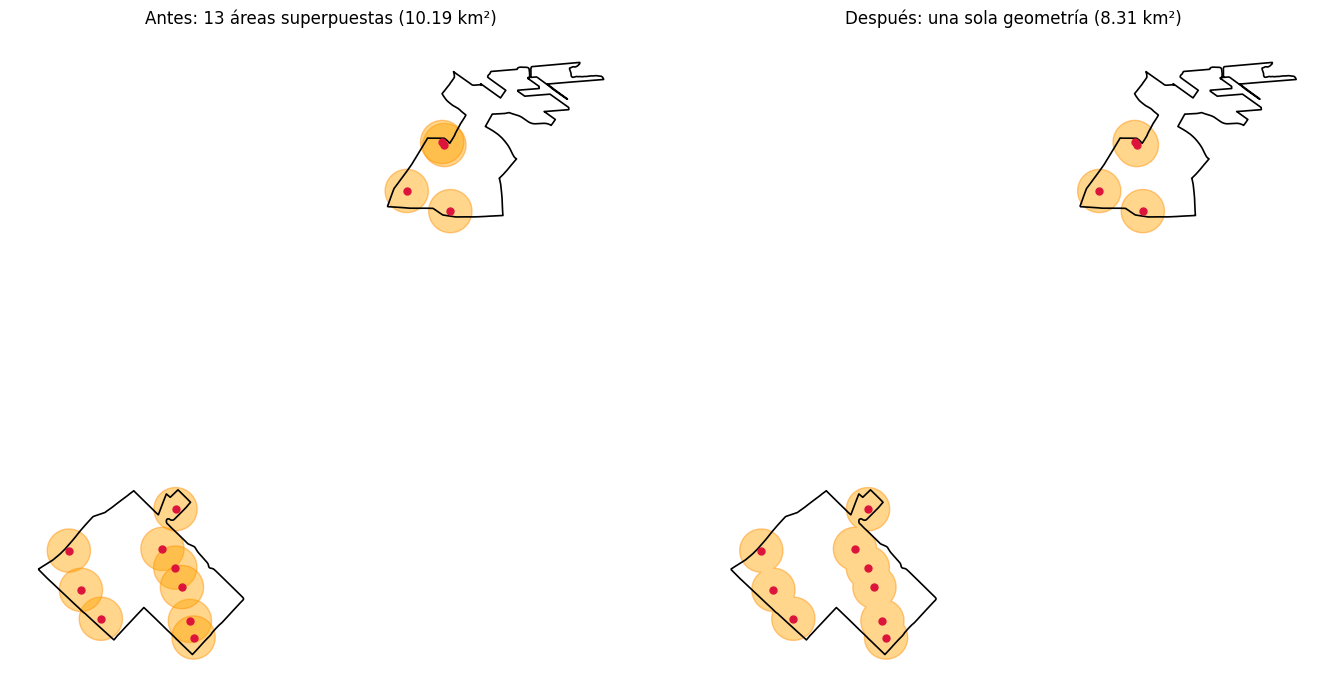

In [171]:
fig, ejes = plt.subplots(1, 2, figsize=(14, 7))

areas_m.plot(ax=ejes[0], facecolor="orange", alpha=0.45,
           edgecolor="darkorange", linewidth=1)
ejes[0].set_title(f"Antes: 13 áreas superpuestas ({areas_m.area.sum() / 1e6:.2f} km²)")

gpd.GeoSeries([cobertura], crs=METRICO).plot(ax=ejes[1], facecolor="orange", alpha=0.45,
                                             edgecolor="darkorange", linewidth=1)
ejes[1].set_title(f"Después: una sola geometría ({cobertura.area / 1e6:.2f} km²)")

for eje in ejes:
    barrios_m.plot(ax=eje, facecolor="none", edgecolor="black", linewidth=1.2)
    salud_m.plot(ax=eje, color="crimson", markersize=25)
    eje.set_axis_off()

plt.tight_layout()
plt.show()

A la izquierda se distinguen los bordes de cada círculo dentro de cada grupo; a la derecha esos
contornos internos desaparecieron. La diferencia de 1,88 km² entre ambas superficies —un 18 %
del total— es exactamente lo que se habría contado dos veces al sumar los círculos por separado.

### ▶️ Paso 3 — La intersección

`intersection` devuelve, para cada barrio, **la parte que tiene en común** con la zona de
cobertura. El resultado no es un número: es una geometría nueva, recortada.

In [172]:
interseccion = barrios_m.geometry.intersection(cobertura)

print("Tipo de resultado:", type(interseccion).__name__)
for barrio, geom in zip(barrios_m["barrio"], interseccion):
    print(f"  {barrio:14} {geom.geom_type:15} {geom.area / 1e6:6.2f} km²")

Tipo de resultado: GeoSeries
  Recoleta       MultiPolygon      1.62 km²
  Villa Lugano   MultiPolygon      4.59 km²


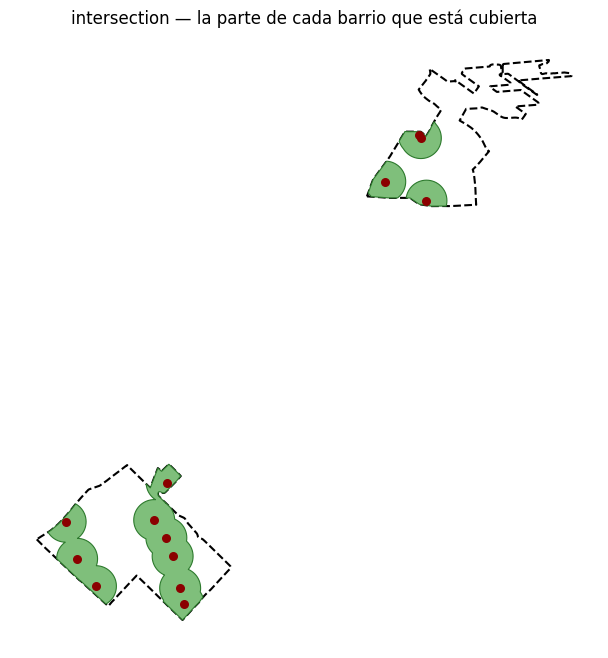

In [174]:
fig, eje = plt.subplots(figsize=(9, 8))

barrios_m.plot(ax=eje, facecolor="none", edgecolor="black",
               linewidth=1.5, linestyle="--")
gpd.GeoSeries(interseccion, crs=METRICO).plot(ax=eje, facecolor="#7fbf7b",
                                              edgecolor="#2d7a2d", linewidth=0.8)
salud_m.plot(ax=eje, color="darkred", markersize=30)

eje.set_title("intersection — la parte de cada barrio que está cubierta")
eje.set_axis_off()
plt.show()

El contorno punteado es el barrio completo; el relleno verde es lo que devolvió la operación.
Todo lo que quedaba fuera de los círculos desapareció de la geometría.

### ▶️ Paso 4 — La diferencia

`difference` es la operación complementaria: devuelve **lo que queda de cada barrio una vez
quitada** la zona de cobertura. Es la respuesta directa a la pregunta de la clase.

In [175]:
diferencia = barrios_m.geometry.difference(cobertura)

for barrio, geom in zip(barrios_m["barrio"], diferencia):
    print(f"  {barrio:14} {geom.geom_type:15} {geom.area / 1e6:6.2f} km² sin cobertura")

  Recoleta       MultiPolygon      5.23 km² sin cobertura
  Villa Lugano   MultiPolygon      4.73 km² sin cobertura


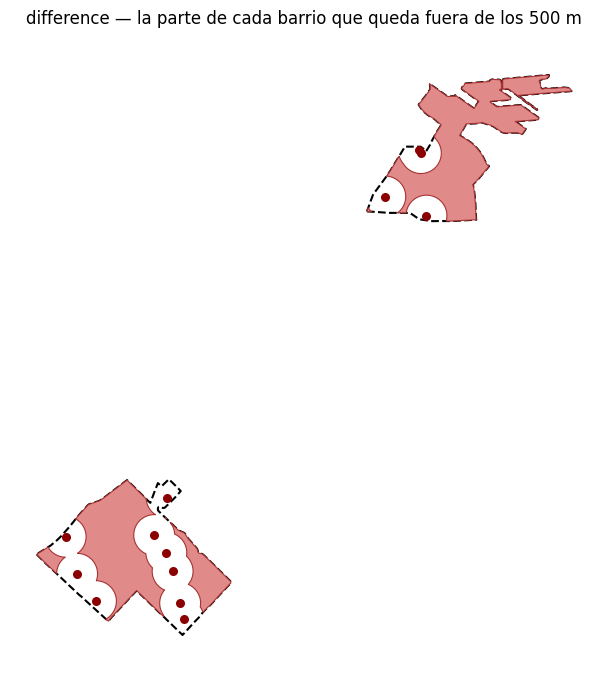

In [176]:
fig, eje = plt.subplots(figsize=(9, 8))

barrios_m.plot(ax=eje, facecolor="none", edgecolor="black",
               linewidth=1.5, linestyle="--")
gpd.GeoSeries(diferencia, crs=METRICO).plot(ax=eje, facecolor="#e08a8a",
                                            edgecolor="#a83232", linewidth=0.8)
salud_m.plot(ax=eje, color="darkred", markersize=30)

eje.set_title("difference — la parte de cada barrio que queda fuera de los 500 m")
eje.set_axis_off()
plt.show()

Las dos geometrías son complementarias: sus superficies suman el barrio completo. Si no lo
hicieran, se habría perdido algo en el camino.

### ▶️ Paso 5 — De la geometría a la variable

Con la superficie de la intersección y la del barrio sale el porcentaje de cobertura, que es la
columna que buscábamos.

In [177]:
barrios_m["superficie_km2"] = barrios_m.area / 1e6
barrios_m["area_cubierta_km2"] = interseccion.area / 1e6
barrios_m["cobertura_500m_perc"] = (barrios_m["area_cubierta_km2"]
                                    / barrios_m["superficie_km2"] * 100)

barrios_m[["barrio", "superficie_km2", "area_cubierta_km2", "cobertura_500m_perc"]].round(2)

,barrio,superficie_km2,area_cubierta_km2,cobertura_500m_perc
0,Recoleta,6.85,1.62,23.70
1,Villa Lugano,9.32,4.59,49.21


### 👀 Las dos piezas juntas

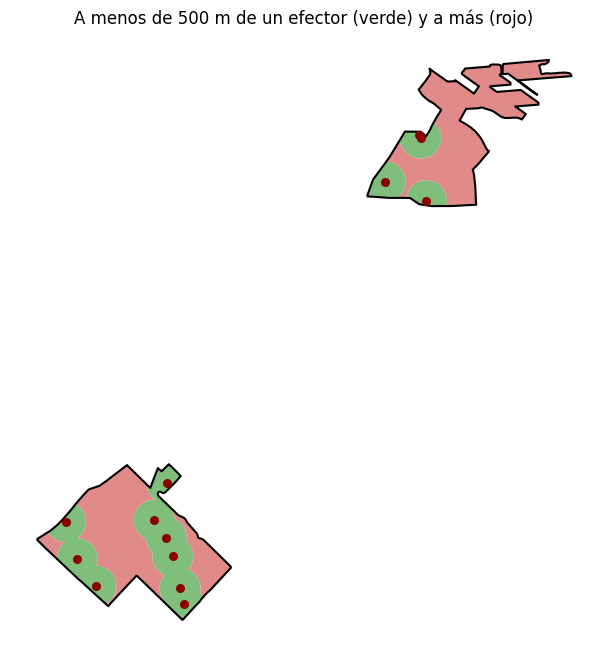

In [178]:
fig, eje = plt.subplots(figsize=(9, 8))

gpd.GeoSeries(interseccion, crs=METRICO).plot(ax=eje, facecolor="#7fbf7b", edgecolor="none")
gpd.GeoSeries(diferencia, crs=METRICO).plot(ax=eje, facecolor="#e08a8a", edgecolor="none")
barrios_m.plot(ax=eje, facecolor="none", edgecolor="black", linewidth=1.5)
salud_m.plot(ax=eje, color="darkred", markersize=30)

eje.set_title(f"A menos de {RADIO_M} m de un efector (verde) y a más (rojo)")
eje.set_axis_off()
plt.show()

### 🔍 Interpretación

A 500 metros, **Villa Lugano tiene el 49 % de su superficie cubierta y Recoleta el 24 %**.

El resultado se explica por la composición de la oferta, no por su cantidad. Recoleta tiene
cuatro efectores públicos y los cuatro son hospitales de alta complejidad, que atienden a toda
la ciudad y están dimensionados para eso. Villa Lugano tiene nueve, y son CeSAC: centros de
atención primaria, de escala barrial, localizados deliberadamente para dar cobertura de
proximidad.

Dos limitaciones que corresponde declarar. La cobertura es de **superficie**, no de población:
el barrio no tiene sus habitantes distribuidos de manera uniforme, y para calcularla sobre
población hace falta el dato por radio censal, que es tema de la Clase 7. Y la distancia es una
dimensión del acceso, no la única: no dice nada sobre horarios, turnos disponibles ni
complejidad de la atención.

---

## 9. Uniones espaciales 1 a 1 y 1 a muchos

**Conceptos clave.** Una **unión espacial** (`gpd.sjoin`) combina los atributos de dos capas a
partir de su relación espacial, sin necesidad de que compartan ninguna columna. La relación se
declara con el **predicado**: `within` (estrictamente adentro), `intersects` (se tocan o se
superponen) o `contains`.

Importa la cardinalidad:

- **1 a 1**: cada elemento de A se corresponde con uno de B. Por ejemplo, asignar a cada punto
  el polígono que lo contiene.
- **1 a muchos**: un polígono contiene varios puntos. La unión duplica el polígono una vez por
  punto, y después se agrega con `groupby`.

**Escenario.** En el bloque 6 le asignamos el barrio a los 13 efectores recorriendo los dos
polígonos con un bucle. Acá hacemos lo mismo sobre los 1.770 equipamientos, con la operación que
GeoPandas provee para eso, y después la usamos en la otra dirección: cuánto equipamiento tiene
cada barrio y de qué tipo.

### ▶️ La unión espacial

En el bloque 6 asignamos el barrio a los 13 efectores con un bucle sobre los dos polígonos.
`sjoin` hace eso mismo en una línea, sin importar cuántas unidades haya, y además incorpora al
punto **todas** las columnas del polígono que lo contiene.

Lo aplicamos a `equip_pt_m`, los 1.770 equipamientos homogeneizados a puntos. La capa ya trae
una columna `barrio`, de cuando se descargó un barrio por vez en la Clase 3: se descarta antes
de la unión, porque si quedaran las dos GeoPandas renombraría ambas como `barrio_left` y
`barrio_right`.

In [179]:
equip_pt_m = equip_pt_m.drop(columns=["barrio"])

equip_en_barrio_m = gpd.sjoin(equip_pt_m, barrios_m[["barrio", "geometry"]],
                              predicate="within").drop(columns="index_right")

print(f"De {len(equip_pt_m)} equipamientos, {len(equip_en_barrio_m)} quedaron asignados")
equip_en_barrio_m[["name", "amenity", "barrio"]].head()

De 1770 equipamientos, 1769 quedaron asignados


,name,amenity,barrio
0,Babieca,restaurant,Recoleta
1,El Noble,fast_food,Recoleta
2,Los Inmortales,restaurant,Recoleta
3,La Continental - Recoleta,fast_food,Recoleta
4,Comisaría Vecinal 2-B,police,Recoleta


Cada punto incorporó la columna `barrio` del polígono que lo contiene. Eso es todo lo que hace
una unión espacial **1 a 1**: transferir al punto el atributo del área donde está. Es la
operación que asigna una encuesta a su radio censal, un hecho registrado a su comuna o un
establecimiento a su partido.

Uno de los 1.770 quedó sin asignar: cae exactamente sobre el límite. `within` exige estar
estrictamente adentro; con `intersects` habría entrado, y en una zona de estudio con muchas
unidades vecinas habría entrado en dos a la vez. La elección del predicado es una decisión del
análisis, no un detalle.

### ▶️ Unión 1 a muchos — cuánto equipamiento tiene cada barrio

El mismo resultado, leído al revés. Cada barrio aparece repetido una vez por cada equipamiento
que contiene, y esa repetición es lo que permite agregar: contar, promediar o sumar por unidad
de análisis.

### 👀 Verificación de la unión

Cada punto pintado con el color del barrio que le asignó el `sjoin`. Un punto de un color dentro
del polígono del otro indicaría un problema de sistema de referencia o de predicado.

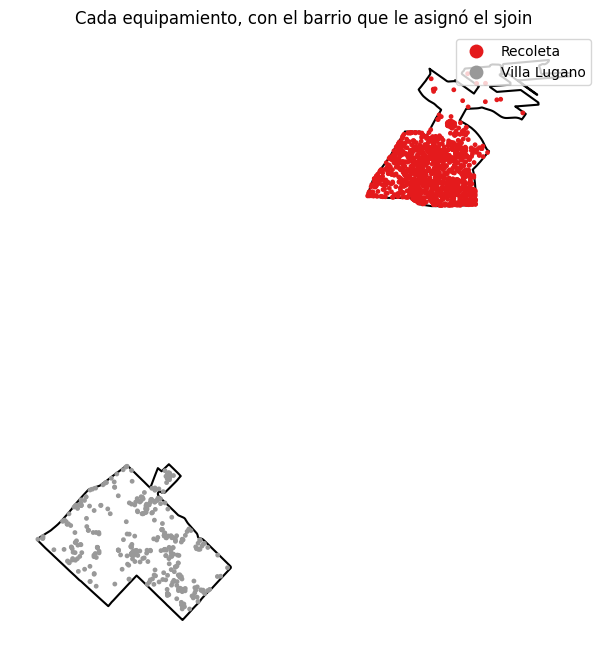

In [180]:
fig, eje = plt.subplots(figsize=(9, 8))

barrios_m.plot(ax=eje, facecolor="none", edgecolor="black", linewidth=1.5)
equip_en_barrio_m.plot(ax=eje, column="barrio", markersize=6, legend=True,
                     cmap="Set1", legend_kwds=dict(loc="upper right"))

eje.set_title("Cada equipamiento, con el barrio que le asignó el sjoin")
eje.set_axis_off()
plt.show()

### ▶️ Agregación

La unión duplicó cada barrio una vez por equipamiento contenido. `groupby` lo resume a un valor
por unidad de análisis, que es lo que la tabla final necesita.

In [182]:
conteo = equip_en_barrio_m.groupby("barrio").size().rename("equipamientos")

TIPOS = ["pharmacy", "school", "cafe", "bank", "clinic"]

por_tipo = barrios_m[["barrio", "superficie_km2"]].copy()
for tipo in TIPOS:
    de_ese_tipo = equip_en_barrio_m[equip_en_barrio_m["amenity"] == tipo]
    cuantos = de_ese_tipo.groupby("barrio").size()
    por_tipo[tipo] = por_tipo["barrio"].map(cuantos).fillna(0).astype(int)

por_tipo

,barrio,superficie_km2,pharmacy,school,cafe,bank,clinic
0,Recoleta,6.852976,85,63,215,56,27
1,Villa Lugano,9.321710,7,86,4,6,11


### ▶️ De conteo a densidad

Los conteos no son comparables entre unidades de distinto tamaño: Recoleta tiene 6,9 km² y
Villa Lugano 9,3. Es la distinción de la Clase 5, ahora aplicada a la producción del dato.

In [183]:
densidad = por_tipo.copy()
for tipo in TIPOS:
    densidad[tipo + "_por_km2"] = (densidad[tipo] / densidad["superficie_km2"]).round(1)

densidad[["barrio"] + [tipo + "_por_km2" for tipo in TIPOS]]

,barrio,pharmacy_por_km2,school_por_km2,cafe_por_km2,bank_por_km2,clinic_por_km2
0,Recoleta,12.4,9.2,31.4,8.2,3.9
1,Villa Lugano,0.8,9.2,0.4,0.6,1.2


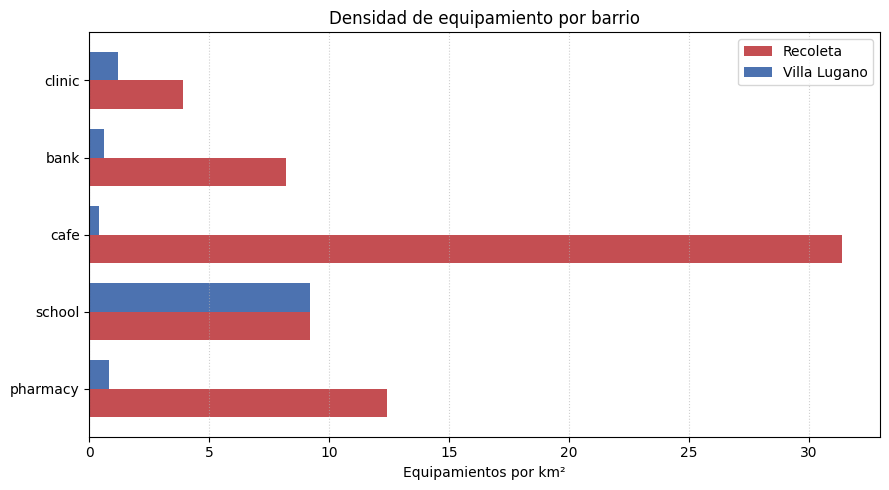

In [184]:
grafico = densidad.set_index("barrio")[[tipo + "_por_km2" for tipo in TIPOS]]
grafico.columns = TIPOS

eje = grafico.T.plot.barh(figsize=(9, 5), color=["#c44e52", "#4c72b0"], width=0.75)
eje.set_xlabel("Equipamientos por km²")
eje.set_ylabel("")
eje.set_title("Densidad de equipamiento por barrio")
eje.legend(title="")
eje.grid(axis="x", linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

### 🔍 Interpretación

Las barras se ordenan en dos grupos. **Farmacias: 12,4 por km² en Recoleta contra 0,8 en Villa
Lugano.** Bancos: 8,2 contra 0,6. Cafés: 31,4 contra 0,4. **Escuelas: 9,2 y 9,2.**

Farmacias, bancos y cafés son equipamiento de mercado y se localizan según la capacidad de
compra. Las escuelas son equipamiento público y se localizan según la población en edad
escolar. Son dos lógicas de localización distintas y dejan huellas territoriales distintas.

La fila de las escuelas cumple además una función de control sobre la fuente: si OpenStreetMap
subregistrara Villa Lugano de manera sistemática, las escuelas también aparecerían subcontadas.

---

## 10. Distancias

**Conceptos clave.** La **distancia euclídea** entre dos geometrías es la separación mínima en
línea recta. `sjoin_nearest` resuelve en una sola operación cuál es el elemento más próximo de
otra capa y a qué distancia está, lo que a mano exigiría comparar todos contra todos.

**Escenario.** La cobertura del bloque 8 responde con un sí o un no: dentro o fuera de los 500
metros. La distancia responde con un número, y por eso admite comparaciones más finas. Vamos a
calcular, para cada equipamiento del barrio, a qué distancia está el efector de salud más
cercano, y a resumir ese valor por barrio.

La distancia es **en línea recta**. La distancia efectiva por la red de calles es siempre mayor,
y la calculamos en la Clase 7.

### ▶️ Distancia al efector más cercano

In [185]:
cercano_m = gpd.sjoin_nearest(
    equip_en_barrio_m,
    salud_m[["nombre", "geometry"]].rename(columns={"nombre": "efector_cercano"}),
    distance_col="dist_salud_m",
).drop(columns="index_right")

cercano_m[["name", "amenity", "barrio", "efector_cercano", "dist_salud_m"]].head()

,name,amenity,barrio,efector_cercano,dist_salud_m
0,Babieca,restaurant,Recoleta,Hospital de Clínicas José de San Martín,584.145051
1,El Noble,fast_food,Recoleta,Hospital de Clínicas José de San Martín,944.630639
2,Los Inmortales,restaurant,Recoleta,Hospital de Clínicas José de San Martín,1165.873806
3,La Continental - Recoleta,fast_food,Recoleta,Hospital General de Agudos Bernardino Rivadavia,791.430280
4,Comisaría Vecinal 2-B,police,Recoleta,Hospital General de Niños Doctor Ricardo Gutié...,414.394672


### 👀 Verificación

Si la operación es correcta, los puntos próximos a un efector deben ser claros y los alejados
oscuros: alrededor de cada efector tiene que verse un halo.

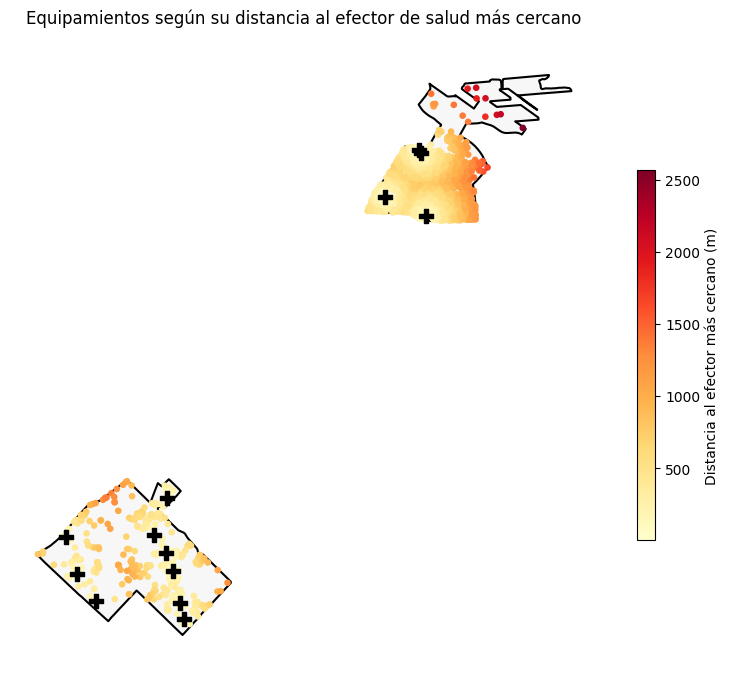

In [186]:
fig, eje = plt.subplots(figsize=(10, 8))

barrios_m.plot(ax=eje, facecolor="#f7f7f7", edgecolor="black", linewidth=1.5)
cercano_m.plot(ax=eje, column="dist_salud_m", cmap="YlOrRd", markersize=14, legend=True,
             legend_kwds=dict(label="Distancia al efector más cercano (m)", shrink=0.6))
salud_m.plot(ax=eje, color="black", marker="P", markersize=90)

eje.set_title("Equipamientos según su distancia al efector de salud más cercano")
eje.set_axis_off()
plt.show()

### ▶️ Resumen por unidad de análisis

`sjoin_nearest` devolvió una distancia por cada equipamiento. La tabla final necesita un valor
por barrio.

In [187]:
resumen_dist = (cercano_m.groupby("barrio")["dist_salud_m"]
                .agg(["count", "mean", "median", "max"]).round(0))
resumen_dist

,count,mean,median,max
barrio,,,,
Recoleta,1379,640.0,604.0,2567.0
Villa Lugano,390,484.0,422.0,1384.0


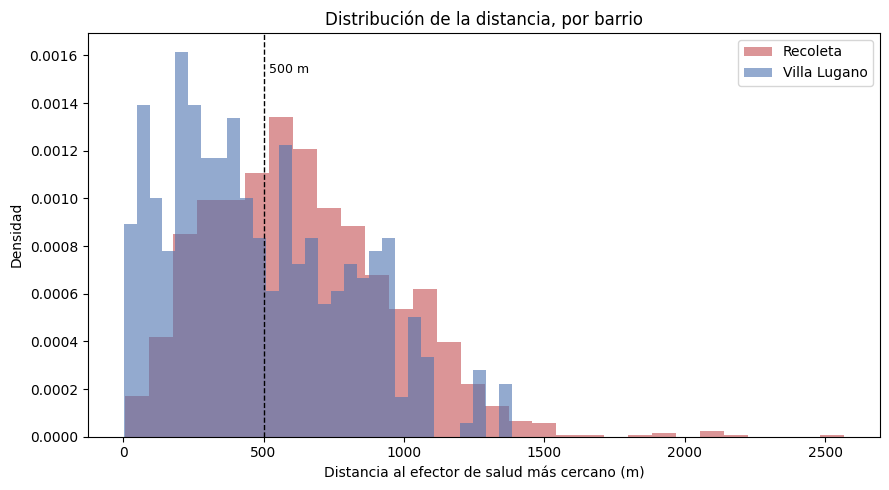

In [188]:
fig, eje = plt.subplots(figsize=(9, 5))

for barrio, color in [("Recoleta", "#c44e52"), ("Villa Lugano", "#4c72b0")]:
    datos = cercano_m.loc[cercano_m["barrio"] == barrio, "dist_salud_m"]
    eje.hist(datos, bins=30, alpha=0.6, label=barrio, color=color, density=True)

eje.axvline(RADIO_M, color="black", linestyle="--", linewidth=1)
eje.text(RADIO_M + 20, eje.get_ylim()[1] * 0.9, f"{RADIO_M} m", fontsize=9)
eje.set_xlabel("Distancia al efector de salud más cercano (m)")
eje.set_ylabel("Densidad")
eje.set_title("Distribución de la distancia, por barrio")
eje.legend()
plt.tight_layout()
plt.show()

### ▶️ Desagregado por tipo de equipamiento

In [189]:
TIPOS_DIST = ["school", "pharmacy", "kindergarten", "cafe"]

filas = []
for tipo in TIPOS_DIST:
    de_ese_tipo = cercano_m[cercano_m["amenity"] == tipo]
    medianas = de_ese_tipo.groupby("barrio")["dist_salud_m"].median().round(0)
    filas.append({"amenity": tipo, **medianas.to_dict()})

pd.DataFrame(filas).set_index("amenity")

,Recoleta,Villa Lugano
amenity,,
school,564.0,353.0
pharmacy,555.0,740.0
kindergarten,604.0,415.0
cafe,613.0,710.0


### 🔍 Interpretación

La distancia mediana de un equipamiento al efector de salud más cercano es de **422 metros en
Villa Lugano y 604 en Recoleta**. El resultado coincide con el del bloque 8, obtenido por otra
vía: dos operaciones independientes sobre las mismas capas conducen a la misma conclusión.

El histograma agrega información que el promedio no contiene. La distribución de Villa Lugano
es angosta y está corrida hacia la izquierda —casi todo su equipamiento se encuentra entre 200
y 700 metros de un CeSAC—, mientras que la de Recoleta tiene una cola que llega a 2,6 km.

El desagregado por tipo es el que admite una lectura sectorial: **las escuelas de Villa Lugano
están a 353 metros medianos de un efector de salud y las de Recoleta a 564**. Para dimensionar
un programa de salud escolar, ése es el valor pertinente y no el promedio general.

---

## 11. La tabla de variables territoriales

### ▶️ Composición

Una fila por unidad de análisis, una columna por variable, la unidad de medida en el nombre.

In [139]:
tabla = barrios_m[["barrio", "superficie_km2", "cobertura_500m_perc"]].copy()

tabla["efectores_salud"]   = tabla["barrio"].map(salud["barrio"].value_counts())
tabla["equipamientos"]     = tabla["barrio"].map(conteo)
tabla["farmacias_por_km2"] = tabla["barrio"].map(
    densidad.set_index("barrio")["pharmacy_por_km2"])
tabla["escuelas_por_km2"]  = tabla["barrio"].map(
    densidad.set_index("barrio")["school_por_km2"])
tabla["dist_salud_m"]      = tabla["barrio"].map(resumen_dist["median"])

tabla.round(1)

,barrio,superficie_km2,cobertura_500m_perc,efectores_salud,equipamientos,farmacias_por_km2,escuelas_por_km2,dist_salud_m
0,Recoleta,6.9,23.7,4,1379,12.4,9.2,604.0
1,Villa Lugano,9.3,49.2,9,390,0.8,9.2,422.0


### ▶️ Exportación

El GeoPackage conserva la geometría y permite continuar el trabajo; el CSV es la tabla para el
informe.

In [140]:
salida = barrios[["barrio", "geometry"]].merge(tabla, on="barrio")

salida.to_file("variables_territoriales_barrios.gpkg", driver="GPKG")
tabla.round(2).to_csv("variables_territoriales_barrios.csv", index=False)

print("variables_territoriales_barrios.gpkg — con geometría")
print("variables_territoriales_barrios.csv  — la tabla")

variables_territoriales_barrios.gpkg — con geometría
variables_territoriales_barrios.csv  — la tabla


En Colab estos archivos quedan en el disco temporal de la sesión y se borran al cerrarla. Para
conservarlos hay que descargarlos desde el panel de archivos o montar Google Drive.

---

## 12. Cierre

### Recorrido

| Familia | Operación | Pregunta que responde | Variable resultante |
|---|---|---|---|
| — | Geocodificación | ¿Cómo convierto direcciones en una capa? | — |
| **Transformar** | `representative_point`, `convex_hull`, `envelope`, `simplify`, `union_all` | ¿Qué forma necesito para la medición que quiero hacer? | — |
| **Superponer** | `intersection`, `difference` | ¿Qué parte de la unidad está dentro de la zona? | `cobertura_500m_perc` |
| **Relacionar** | `sjoin` + `groupby` | ¿Qué contiene cada unidad? | `farmacias_por_km2` |
| **Medir** | `sjoin_nearest` | ¿A qué distancia está lo más próximo? | `dist_salud_m` |

### Conclusión de la clase

Una variable territorial no se observa: se construye, y cada una incorpora decisiones que no
quedan registradas en el nombre de la columna. El radio de 500 metros, el predicado `within`, la
opción de normalizar por superficie en lugar de por población: ninguna figura en
`cobertura_500m_perc`, y todas modifican el valor.

De ahí la verificación visual en cada paso. Dos veces en esta clase el gráfico aportó lo que la
tabla no mostraba: el halo de `sjoin_nearest`, que confirma que la operación hizo lo que
declaraba, y las curvas de sensibilidad que no se cruzan, que es lo que convierte una
observación en una conclusión sostenible.

### Glosario

| Término | Definición |
|---|---|
| **Operación espacial** | Procedimiento que toma una o más geometrías y devuelve una geometría, una relación o una medida, calculada a partir de su forma y su posición. |
| **Variable territorial** | Atributo de una unidad del espacio obtenido de la relación entre dos o más capas. |
| **Geocodificación** | Conversión de una dirección en coordenadas. La inversa parte de la coordenada. |
| **Punto representativo** | Punto garantizado interior a una geometría. Homogeneiza capas con tipos mezclados. |
| **Rectángulo contenedor** (*envelope*) | El rectángulo mínimo, de lados paralelos a los ejes, que contiene a la geometría. |
| **Área de influencia** (*buffer*) | Zona que rodea a una geometría hasta una distancia dada. |
| **Envolvente convexa** (*convex hull*) | Polígono convexo mínimo que contiene a la geometría. |
| **Simplificación** | Reducción de vértices conservando la forma general, con una tolerancia declarada. |
| **Disolución** (`union_all`) | Fusión de varias geometrías en una, eliminando superposiciones. |
| **Superposición** (*overlay*) | Corte de una capa contra otra: `intersection`, `difference`, `union`. |
| **Unión espacial** (`sjoin`) | Combinación de atributos de dos capas según su relación espacial. |
| **Predicado espacial** | Relación que la unión espacial evalúa: `within`, `intersects`, `contains`. |
| **Cobertura** | Porcentaje de la superficie de una unidad contenido en un área de influencia. |

### Autoevaluación

1. El porcentaje de cobertura de una unidad resultó 137 %. ¿Qué paso se omitió?
2. Se quiere medir la distancia de cada radio censal al hospital más cercano. ¿Qué
   transformación de geometría se requiere primero, y qué supuesto introduce?
3. Un `sjoin` con `within` dejó 40 de 1.000 puntos sin asignar. ¿Cuáles son las dos
   explicaciones posibles y cómo se distinguen?

### Clase 7

Las distancias de hoy son en línea recta. La distancia efectiva por la red de calles es mayor, y
la próxima clase mide cuánto: vamos a comparar el área de influencia circular de 500 metros con
la superficie realmente alcanzable caminando en ese tiempo.

También resolvemos el problema que quedó abierto en el bloque 8: cómo transferir una variable de
una división territorial a otra —de radios censales a barrios— para calcular la cobertura sobre
población y no sobre superficie.

---

## 13. Referencias

- de Smith, M. J., Goodchild, M. F. y Longley, P. A. (2018). *Geospatial Analysis: A
  Comprehensive Guide to Principles, Techniques and Software Tools* (6.ª ed.), caps. 4 y 7.
- Rey, S., Arribas-Bel, D. y Wolf, L. J. (2023). *Geographic Data Science with Python*, cap. 8
  "Spatial Feature Engineering". CRC Press.
- Instituto Geográfico Nacional (2024). *Capas de Sistema de Información Geográfica — Salud*.
  Geoservicio WFS, capa `ign:salud_020801`.
- Ministerio de Salud del Gobierno de la Ciudad de Buenos Aires. *Centros de Salud y Acción
  Comunitaria (CeSAC)*.
- Documentación de Shapely: predicados binarios y operaciones de conjunto.
  https://shapely.readthedocs.io/en/stable/manual.html